In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings
from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

import shap
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
BASE_DIR = "../"
DATA_PATH = os.path.join(BASE_DIR, "data", "cancer_data_eng.csv")
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
RANDOM_STATE = 42
N_SAMPLES = 10000

In [3]:
print("\n[0] 加载数据...")
df = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin-1')
df['target'] = df['Status.Vital'].map({'VIVO': 1, 'MORTO': 0})
df = df.dropna(subset=['target'])
np.random.seed(RANDOM_STATE)
if len(df) > N_SAMPLES:
    idx = np.random.choice(len(df), N_SAMPLES, replace=False)
    df = df.iloc[idx].copy()

feature_cols = ['Age', 'year', 'Code.Profession', 'Diagnostic.means',
                'Extension', 'Raca.Color']
df_feat = df[feature_cols + ['target']].copy()

cat_cols = ['Diagnostic.means', 'Extension', 'Raca.Color']
for col in cat_cols:
    le = LabelEncoder()
    non_null = df_feat[col].dropna().astype(str)
    le.fit(non_null)
    mc = non_null.value_counts().index[0]
    def encode(x, le=le, mc=mc):
        if pd.isna(x): return np.nan
        xs = str(x)
        return le.transform([xs])[0] if xs in le.classes_ else le.transform([mc])[0]
    df_feat[col] = df_feat[col].apply(encode)

X = df_feat[feature_cols].astype(float).values
y = df_feat['target'].values
feature_names = np.array(feature_cols)

n_pos = (y == 1).sum()
print(f"    总样本: {len(X):,}  VIVO: {n_pos:,} ({n_pos/len(X)*100:.2f}%)")

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_tr_imp = imputer.fit_transform(X_tr)
X_te_imp = imputer.transform(X_te)
X_tr_final = scaler.fit_transform(X_tr_imp)
X_te_final = scaler.transform(X_te_imp)



[0] 加载数据...
    总样本: 10,000  VIVO: 4,123 (41.23%)


In [4]:

# ============================================================================
# 1. 训练模型 + SHAP 计算
# ============================================================================
print("\n[1] 训练 Random Forest + SHAP TreeExplainer...")
model = RandomForestClassifier(
    n_estimators=200, max_depth=8, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1)
model.fit(X_tr_final, y_tr)
y_prob = model.predict_proba(X_te_final)[:, 1]
auc = roc_auc_score(y_te, y_prob)
print(f"    RF AUC = {auc:.4f}")

n_shap = 500
X_shap = X_te_final[:n_shap]

explainer = shap.TreeExplainer(model)
shap_values_full = explainer.shap_values(X_shap)

if isinstance(shap_values_full, list):
    sv = shap_values_full[1]
else:
    sv = shap_values_full
    if sv.ndim == 3:
        sv = sv[:, :, 1]

shap_importance = np.abs(sv).mean(0)
feature_order = np.argsort(shap_importance)[::-1]

print(f"    SHAP 形状: {sv.shape}")
print(f"    特征排名: {[feature_names[i] for i in feature_order]}")
print(f"    Mean |SHAP|: {[f'{shap_importance[i]:.4f}' for i in feature_order]}")


[1] 训练 Random Forest + SHAP TreeExplainer...
    RF AUC = 0.9104
    SHAP 形状: (500, 6)
    特征排名: [np.str_('Diagnostic.means'), np.str_('year'), np.str_('Raca.Color'), np.str_('Extension'), np.str_('Code.Profession'), np.str_('Age')]
    Mean |SHAP|: ['0.2421', '0.1274', '0.0421', '0.0330', '0.0287', '0.0280']


In [5]:
# ============================================================================
# 2. 交互效应扫描 —— 对每个特征，找到最强交互特征
# ============================================================================
print("\n" + "=" * 70)
print("[2] 交互效应扫描 — 逐个特征搜索最强交互对")
print("=" * 70)

n_features = len(feature_names)
interaction_matrix = np.zeros((n_features, n_features))

print(f"\n{'Main Feature':<20} {'Strength':<12} {'Interaction Feature':<20} {'Method':<12}")
print(f"{'-'*20} {'-'*12} {'-'*20} {'-'*12}")

# 计算所有交互对
interaction_pairs = []
for i in range(n_features):
    best_strength = 0
    best_j = -1
    best_method = "N/A"
    for j in range(n_features):
        if i == j:
            continue
        # 方法 1: |corr(SHAP_i, X_j)| — SHAP 值与交互特征原始值的相关性
        corr_val, _ = pearsonr(sv[:, i], X_shap[:, j])
        strength_method1 = abs(corr_val)

        # 方法 2: |corr(SHAP_i, SHAP_j)| — 两个 SHAP 值的相关性
        corr_shap, _ = pearsonr(sv[:, i], sv[:, j])
        strength_method2 = abs(corr_shap)

        # 取两种方法中更强的一个，并记录用的是哪个
        if strength_method1 >= strength_method2:
            strength = strength_method1
            method = "SHAP_i × X_j"
        else:
            strength = strength_method2
            method = "SHAP_i × SHAP_j"

        interaction_matrix[i, j] = strength

        if strength > best_strength:
            best_strength = strength
            best_j = j
            best_method = method

    interaction_pairs.append({
        'main_idx': i,
        'main_name': feature_names[i],
        'interact_idx': best_j,
        'interact_name': feature_names[best_j],
        'strength': best_strength,
        'method': best_method
    })
    print(f"  {feature_names[i]:<20} {best_strength:<12.4f} {feature_names[best_j]:<20} {best_method:<12}")


[2] 交互效应扫描 — 逐个特征搜索最强交互对

Main Feature         Strength     Interaction Feature  Method      
-------------------- ------------ -------------------- ------------
  Age                  0.1510       Extension            SHAP_i × SHAP_j
  year                 0.1814       Diagnostic.means     SHAP_i × X_j
  Code.Profession      0.1617       Raca.Color           SHAP_i × SHAP_j
  Diagnostic.means     0.2036       Raca.Color           SHAP_i × X_j
  Extension            0.2000       Diagnostic.means     SHAP_i × SHAP_j
  Raca.Color           0.1773       Diagnostic.means     SHAP_i × SHAP_j



[3] SHAP 交互依赖图 — 2×2 面板
  [图] 17a_shap_interactions_panel.png (Top 4 特征交互面板) 已保存


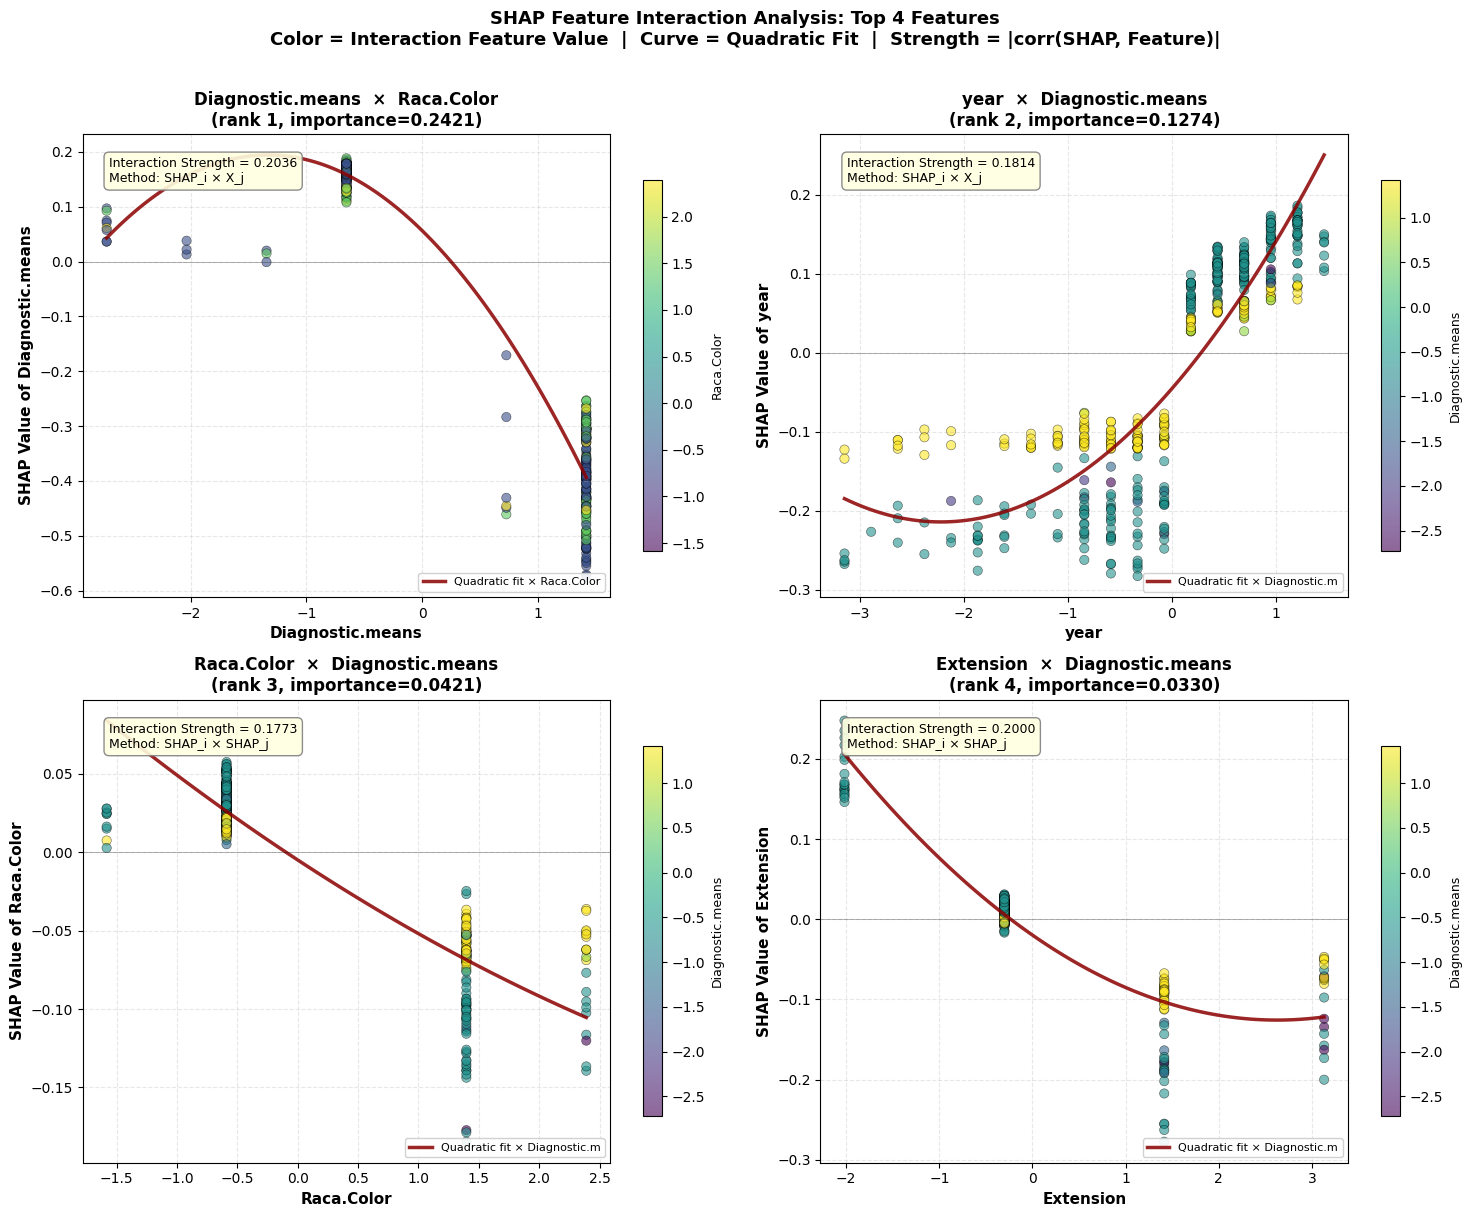

In [6]:
# ============================================================================
# 3. SHAP 交互依赖图 (Top 4 主要特征, 2×2 面板)
# ============================================================================
print("\n" + "=" * 70)
print("[3] SHAP 交互依赖图 — 2×2 面板")
print("=" * 70)

top_n = min(4, n_features)
top_idx_list = feature_order[:top_n]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for p_idx, main_rank in enumerate(range(top_n)):
    ax = axes[p_idx]
    main_idx = top_idx_list[main_rank]
    main_name = feature_names[main_idx]

    # 获取最强交互特征
    pair_info = interaction_pairs[main_idx]
    interact_idx = pair_info['interact_idx']
    interact_name = pair_info['interact_name']
    strength = pair_info['strength']

    main_values = X_shap[:, main_idx]
    shap_vals = sv[:, main_idx]
    interact_values = X_shap[:, interact_idx]

    # 散点图: 按交互特征值着色
    scatter = ax.scatter(
        main_values, shap_vals, c=interact_values,
        cmap='viridis', alpha=0.6, s=45,
        edgecolors='black', linewidth=0.4)

    # 二次拟合趋势线
    mask = ~(np.isnan(main_values) | np.isnan(shap_vals))
    if np.sum(mask) > 10:
        x_clean, y_clean = main_values[mask], shap_vals[mask]
        z = np.polyfit(x_clean, y_clean, 2)
        p = np.poly1d(z)
        x_range = np.linspace(np.min(x_clean), np.max(x_clean), 100)
        ax.plot(x_range, p(x_range), color='darkred', linewidth=2.5,
                alpha=0.85, label=f'Quadratic fit × {interact_name[:12]}')

    # 交互强度标注框
    ax.text(0.05, 0.95,
            f'Interaction Strength = {strength:.4f}\nMethod: {pair_info["method"]}',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.9))

    # 零线
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.4)

    ax.set_xlabel(f'{main_name}', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'SHAP Value of {main_name}', fontsize=11, fontweight='bold')
    ax.set_title(f'{main_name}  ×  {interact_name}\n(rank {main_rank+1}, importance={shap_importance[main_idx]:.4f})',
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')

    # 图例
    if ax.get_legend_handles_labels()[0]:
        ax.legend(loc='lower right', fontsize=8, framealpha=0.9)

    # 颜色条
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
    cbar.set_label(interact_name, fontsize=9)

fig.suptitle('SHAP Feature Interaction Analysis: Top 4 Features\n'
             'Color = Interaction Feature Value  |  Curve = Quadratic Fit  |  Strength = |corr(SHAP, Feature)|',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "17a_shap_interactions_panel.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 17a_shap_interactions_panel.png (Top 4 特征交互面板) 已保存")


[4] 完整交互强度矩阵热图
  [图] 17b_interaction_matrix.png 已保存


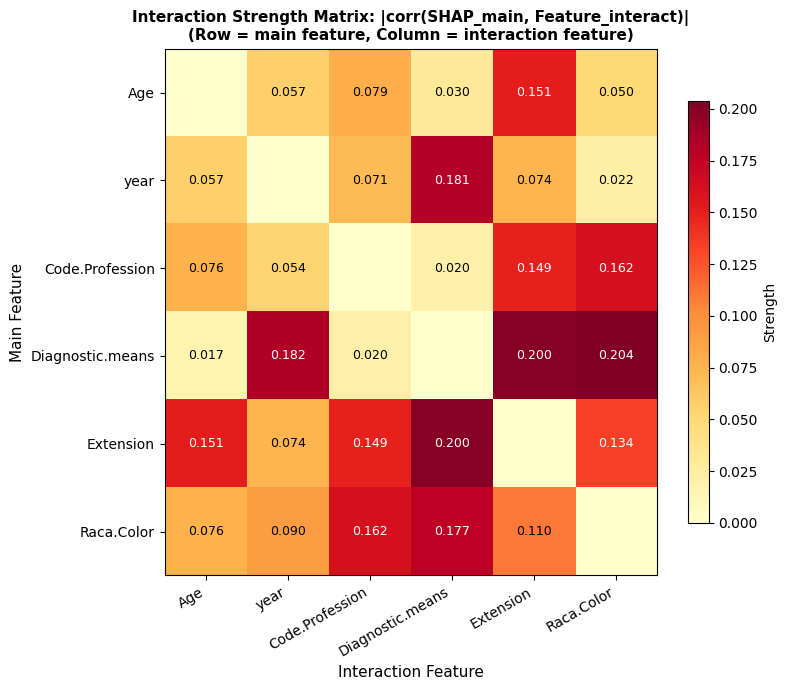

In [7]:
# ============================================================================
# 4. 完整交互矩阵热图
# ============================================================================
print("\n" + "=" * 70)
print("[4] 完整交互强度矩阵热图")
print("=" * 70)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(interaction_matrix, cmap='YlOrRd', aspect='auto', vmin=0)

ax.set_xticks(range(n_features))
ax.set_xticklabels(feature_names, rotation=30, ha='right')
ax.set_yticks(range(n_features))
ax.set_yticklabels(feature_names)

# 添加数值标注
for i in range(n_features):
    for j in range(n_features):
        if i != j:
            val = interaction_matrix[i, j]
            color = 'white' if val > interaction_matrix.max() * 0.6 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9, color=color)

ax.set_xlabel('Interaction Feature', fontsize=11)
ax.set_ylabel('Main Feature', fontsize=11)
ax.set_title('Interaction Strength Matrix: |corr(SHAP_main, Feature_interact)|\n'
             '(Row = main feature, Column = interaction feature)',
             fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='Strength', shrink=0.8)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "17b_interaction_matrix.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 17b_interaction_matrix.png 已保存")


[5] 交互强度排名条形图
  [图] 17c_interaction_ranking.png 已保存


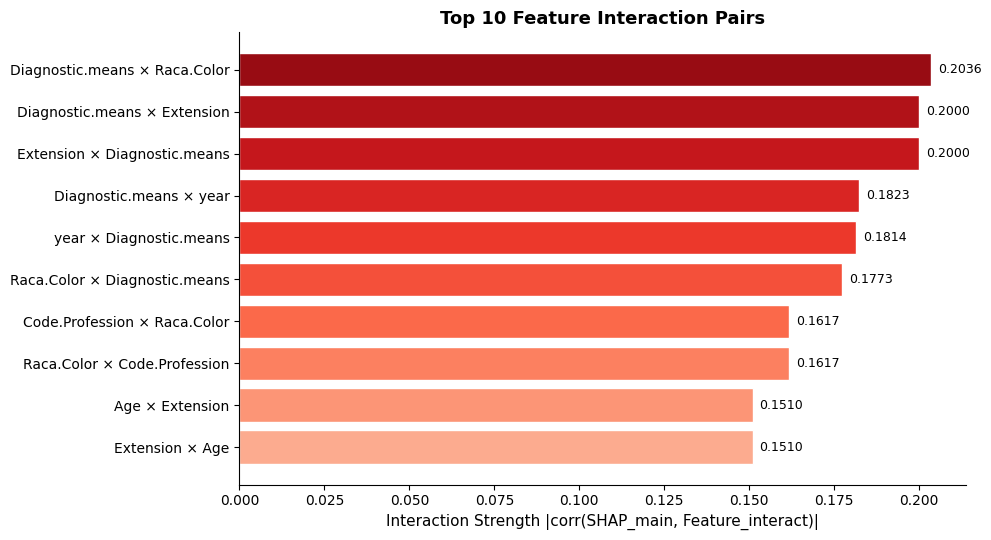

In [8]:
# ============================================================================
# 5. 交互强度排名图 (条形图)
# ============================================================================
print("\n" + "=" * 70)
print("[5] 交互强度排名条形图")
print("=" * 70)

all_pairs = []
for i in range(n_features):
    for j in range(n_features):
        if i != j:
            all_pairs.append((feature_names[i], feature_names[j], interaction_matrix[i, j]))
all_pairs.sort(key=lambda x: x[2], reverse=True)

top_pairs = all_pairs[:10]

fig, ax = plt.subplots(figsize=(10, 5.5))
pair_labels = [f'{p[0]} × {p[1]}' for p in top_pairs]
pair_values = [p[2] for p in top_pairs]

colors_bar = plt.cm.Reds(np.linspace(0.3, 0.9, len(top_pairs)))
bars = ax.barh(range(len(top_pairs)), pair_values, color=colors_bar[::-1], edgecolor='white')
ax.set_yticks(range(len(top_pairs)))
ax.set_yticklabels(pair_labels)
ax.set_xlabel('Interaction Strength |corr(SHAP_main, Feature_interact)|', fontsize=11)
ax.set_title('Top 10 Feature Interaction Pairs', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# 数值标注
for i, (bar, val) in enumerate(zip(bars, pair_values)):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', ha='left', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "17c_interaction_ranking.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 17c_interaction_ranking.png 已保存")


[6] 深度交互对比: year 与所有其他特征的交互
  [图] 17d_year_interaction_deepdive.png 已保存


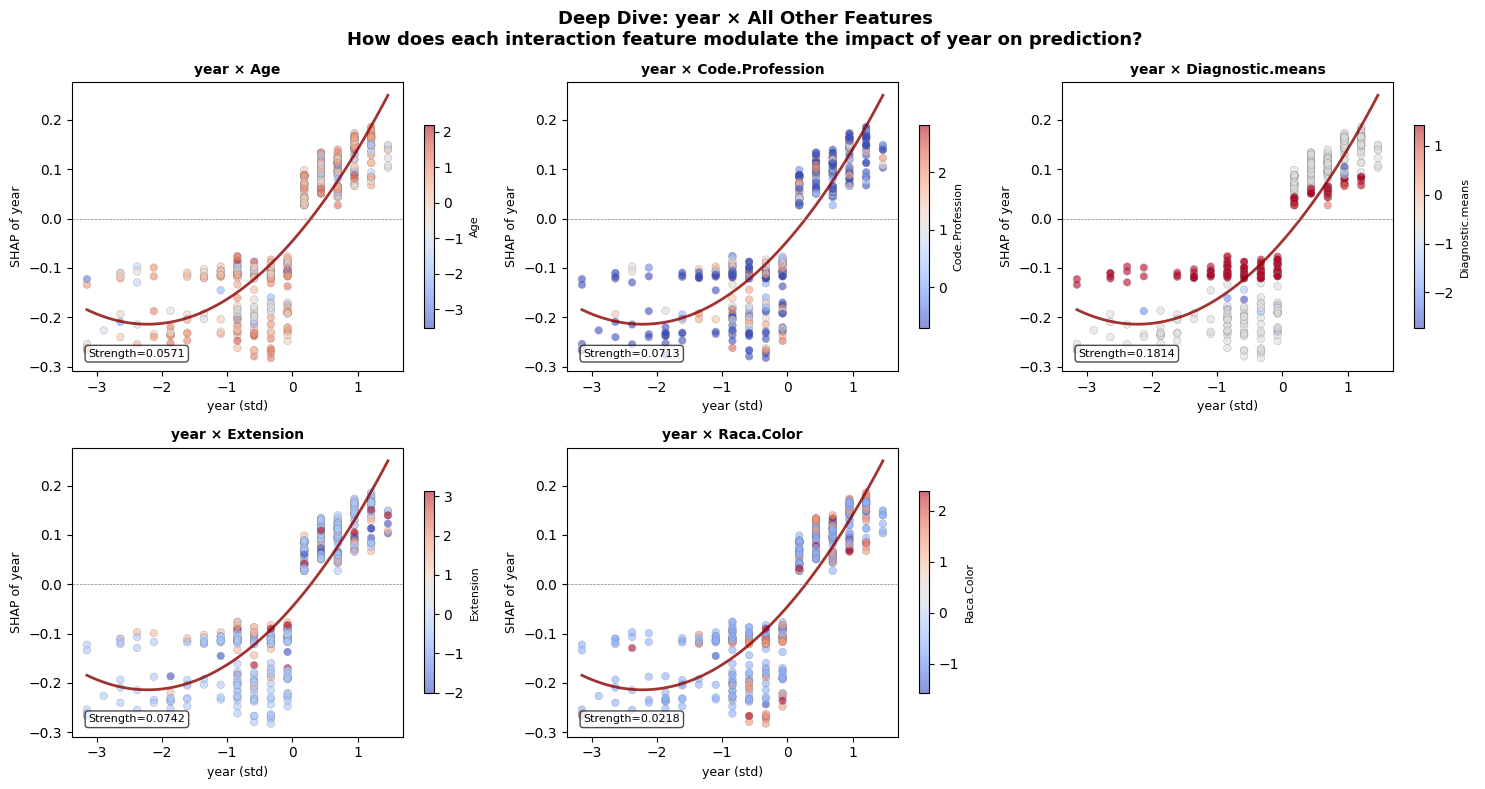

In [9]:
# ============================================================================
# 6. 单个特征的深度交互对比 (以 year 为例, 显示所有交互)
# ============================================================================
print("\n" + "=" * 70)
print("[6] 深度交互对比: year 与所有其他特征的交互")
print("=" * 70)

year_idx = list(feature_names).index('year')
other_indices = [j for j in range(n_features) if j != year_idx]
n_others = len(other_indices)

# 布局: 每行 3 个, 总共 5 个其他特征, 2 行
n_cols = 3
n_rows = int(np.ceil(n_others / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()
ax_idx = 0

for j in other_indices:
    ax = axes[ax_idx]
    other_name = feature_names[j]

    x_vals = X_shap[:, year_idx]
    y_vals = sv[:, year_idx]
    color_vals = X_shap[:, j]

    scatter = ax.scatter(x_vals, y_vals, c=color_vals,
                         cmap='coolwarm', alpha=0.6, s=30,
                         edgecolors='gray', linewidth=0.3)

    # 二次拟合
    mask = ~(np.isnan(x_vals) | np.isnan(y_vals))
    if np.sum(mask) > 10:
        z = np.polyfit(x_vals[mask], y_vals[mask], 2)
        p = np.poly1d(z)
        x_range = np.linspace(np.min(x_vals[mask]), np.max(x_vals[mask]), 100)
        ax.plot(x_range, p(x_range), color='darkred', linewidth=2, alpha=0.8)
        ax.text(0.05, 0.05, f'Strength={interaction_matrix[year_idx, j]:.4f}',
                transform=ax.transAxes, fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_xlabel('year (std)', fontsize=9)
    ax.set_ylabel('SHAP of year', fontsize=9)
    ax.set_title(f'year × {other_name}', fontsize=10, fontweight='bold')

    cbar = plt.colorbar(scatter, ax=ax, shrink=0.7)
    cbar.set_label(other_name, fontsize=8)
    ax_idx += 1

# 隐藏多余的子图
for k in range(ax_idx, len(axes)):
    axes[k].axis('off')

fig.suptitle('Deep Dive: year × All Other Features\n'
             'How does each interaction feature modulate the impact of year on prediction?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "17d_year_interaction_deepdive.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 17d_year_interaction_deepdive.png 已保存")


[7] 交互度量方法对比: SHAP_i × X_j  vs  SHAP_i × SHAP_j
  [图] 17e_method_comparison.png 已保存

  方法对比:
  Pair                              M1 (SHAP×X) M2 (SHAP×SHAP)        Δ
  ------------------------------ -------------- -------------- --------
  Age × year                         0.0331         0.0571  -0.0240
  Age × Code.Profession              0.0788         0.0728  +0.0060
  Age × Diagnostic.means             0.0295         0.0070  +0.0225
  Age × Extension                    0.0582         0.1510  -0.0928
  Age × Raca.Color                   0.0503         0.0410  +0.0094
  year × Code.Profession              0.0713         0.0543  +0.0170
  year × Diagnostic.means             0.1814         0.1778  +0.0036
  year × Extension                    0.0311         0.0742  -0.0431
  year × Raca.Color                   0.0170         0.0218  -0.0049
  Code.Profession × Diagnostic.means             0.0054         0.0202  -0.0147
  Code.Profession × Extension                    0.1338         0.

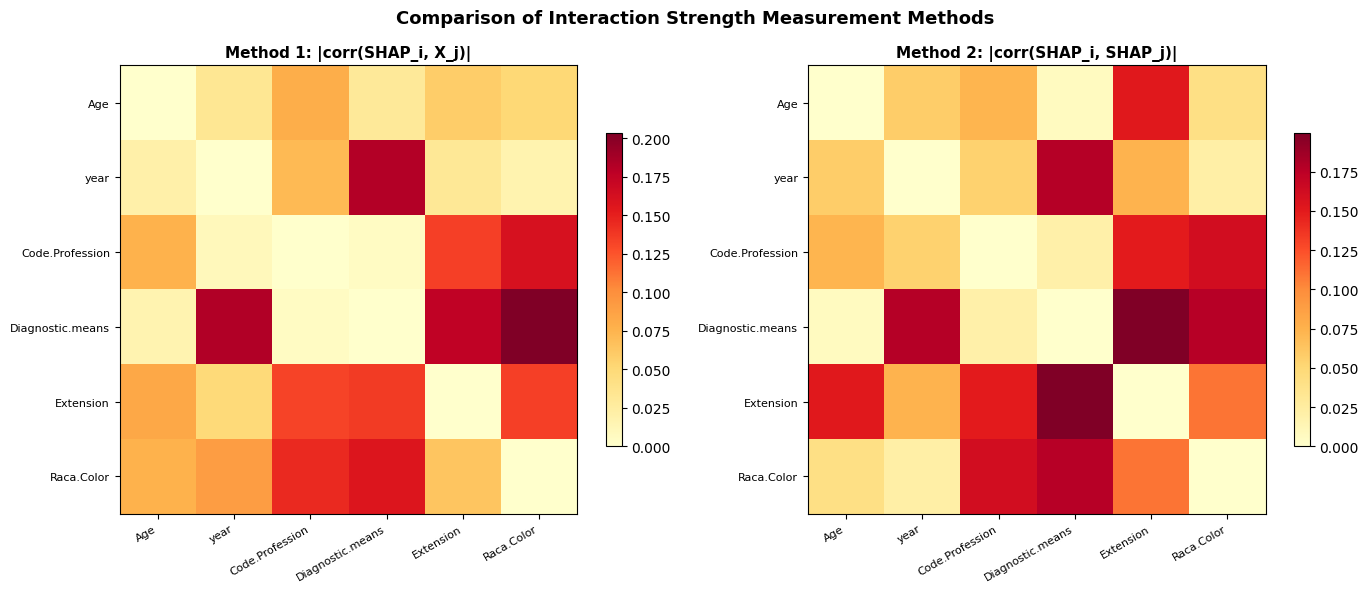

In [10]:
# ============================================================================
# 7. 方法比较: 两种交互强度度量的对比
# ============================================================================
print("\n" + "=" * 70)
print("[7] 交互度量方法对比: SHAP_i × X_j  vs  SHAP_i × SHAP_j")
print("=" * 70)

method1_matrix = np.zeros((n_features, n_features))
method2_matrix = np.zeros((n_features, n_features))

for i in range(n_features):
    for j in range(n_features):
        if i == j:
            continue
        corr_m1, _ = pearsonr(sv[:, i], X_shap[:, j])
        method1_matrix[i, j] = abs(corr_m1)
        corr_m2, _ = pearsonr(sv[:, i], sv[:, j])
        method2_matrix[i, j] = abs(corr_m2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, matrix, title, method_name in [
    (axes[0], method1_matrix, 'Method 1: |corr(SHAP_i, X_j)|', 'm1'),
    (axes[1], method2_matrix, 'Method 2: |corr(SHAP_i, SHAP_j)|', 'm2')
]:
    im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto', vmin=0)
    ax.set_xticks(range(n_features))
    ax.set_xticklabels(feature_names, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(n_features))
    ax.set_yticklabels(feature_names, fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.7)

plt.suptitle('Comparison of Interaction Strength Measurement Methods',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "17e_method_comparison.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 17e_method_comparison.png 已保存")

# 方法比较: 打印一致和不一致的交互对
print("\n  方法对比:")
print(f"  {'Pair':<30} {'M1 (SHAP×X)':>14} {'M2 (SHAP×SHAP)':>14} {'Δ':>8}")
print(f"  {'-'*30} {'-'*14} {'-'*14} {'-'*8}")
for i in range(n_features):
    for j in range(i + 1, n_features):
        m1 = method1_matrix[i, j]
        m2 = method2_matrix[i, j]
        delta = m1 - m2
        print(f"  {feature_names[i]} × {feature_names[j]:<20} {m1:>14.4f} {m2:>14.4f} {delta:>+8.4f}")